In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pickle

In [5]:
saldf=pd.read_csv('/content/drive/MyDrive/Food_Time new.csv')

In [6]:
 saldf.head()

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333


In [7]:
saldf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Traffic_Level                9085 non-null   object 
 1   ID                           10000 non-null  object 
 2   Delivery_person_ID           10000 non-null  object 
 3   weather_description          9995 non-null   object 
 4   Type_of_order                10000 non-null  object 
 5   Type_of_vehicle              10000 non-null  object 
 6   Delivery_person_Age          10000 non-null  int64  
 7   Delivery_person_Ratings      10000 non-null  float64
 8   Restaurant_latitude          10000 non-null  object 
 9   Restaurant_longitude         10000 non-null  object 
 10  Delivery_location_latitude   10000 non-null  object 
 11  Delivery_location_longitude  10000 non-null  object 
 12  temperature                  9995 non-null   float64
 13  humidity         

In [8]:
saldf.isnull().sum()

,0
Traffic_Level,915
ID,0
Delivery_person_ID,0
weather_description,5
Type_of_order,0
Type_of_vehicle,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0


In [9]:
saldf.dropna(inplace=True, how='all')

In [10]:
saldf.isnull().sum()

,0
Traffic_Level,915
ID,0
Delivery_person_ID,0
weather_description,5
Type_of_order,0
Type_of_vehicle,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0


In [11]:
LR=LinearRegression()

In [12]:
inp = saldf[['humidity']]
out = saldf[['precipitation']]
Train_data=pd.concat([inp,out],axis=1)
train=Train_data.dropna()

In [13]:
inp1=train[['humidity']]
out1=train[['precipitation']]

In [14]:
LR=LinearRegression()
LR.fit(inp1,out1)

LinearRegression()

In [15]:
print(LR.coef_)      # if numbers appear → model is fitted ✅


[[0.00108791]]


In [16]:
with open("food.pkl", "wb") as f:
    pickle.dump(LR, f)

print("Model saved successfully")


Model saved successfully


In [17]:
LR.predict([[5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[-0.05030881]])

In [18]:
import pickle

# model is your trained model
with open("LinearRegression().pkl", "wb") as f:
    pickle.dump(LinearRegression(), f)

print("Model saved as model.pkl")

Model saved as model.pkl


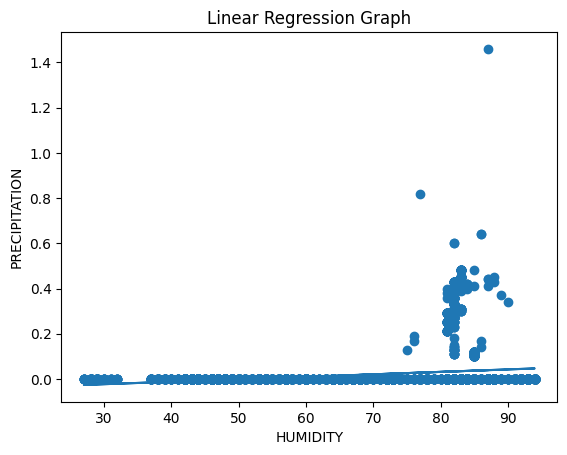

In [20]:
plt.scatter(inp, out)
plt.plot(inp1, LR.predict(inp1))
plt.xlabel("HUMIDITY")
plt.ylabel("PRECIPITATION")
plt.title("Linear Regression Graph")
plt.show()